# Проект. Выявление рисков в доставке


## Введение

Проект посвящён решению прикладной задачи для логистической компании CargaPronto: выявлению рисков задержек доставки ещё на этапе оформления заказа. Ключевая идея — использовать профилирование клиентов (сегментацию) как инструмент предиктивной аналитики, чтобы заранее выделять заказы с повышенной вероятностью задержки и принимать меры (например, корректировать сроки, менять маршрут или тип перевозки).

В основе подхода — комбинация классических методов машинного обучения и кластерной сегментации: с одной стороны, прогнозная модель (логистическая регрессия и CatBoost), с другой — кластеризация по географии и поведенческим признакам клиентов. Это позволяет превратить «сырые» характеристики клиентов и заказов в информативные признаки, которые модель может использовать для более точного прогноза.

Учитывая специфику данных (один клиент делает много заказов, географические выбросы, смешанный тип признаков), стандартные методы предобработки и разбиения данных здесь неприменимы: требуется защита от утечки данных через клиентов, аккуратная работа с географическими аномалиями и корректная подготовка признаков для кластеризации.

### Цель работы

Доказать бизнесу, что профилирование клиентов (выделение сегментов по географии и поведению) позволяет повысить качество прогноза риска задержки доставки по сравнению с моделью, использующей только признаки самого заказа. Формальным критерием успеха считается достижение значения метрики ROC‑AUC > 0.75 на тестовой выборке.

### Задачи проекта

- Загрузить и провести технический аудит данных: проверить типы данных, пропуски, дубликаты, целостность ID (соответствие заказов и профилей клиентов).
- Подготовить временные признаки: преобразовать дату заказа в формат datetime и создать производные признаки (месяц, день недели, час).
- Выполнить EDA и очистить данные:
 - проверить баланс целевой переменной;
 - выявить и удалить географические аномалии по долготе (диапазон –125 до –20);
 - убедиться, что удаление аномальных профилей клиентов сопровождается удалением связанных заказов (сохранение целостности данных);
 - проанализировать корреляции признаков с целевой переменной (в том числе с помощью phik).
- Разделить данные на выборки без утечки по клиентам: использовать GroupShuffleSplit для разделения заказов на обучающую, валидационную и тестовую выборки в пропорции 60:20:20 с непересекающимися множествами customer_id.
- Построить базовую модель прогноза: обучить логистическую регрессию и CatBoostClassifier на признаках заказа и оценить их качество на валидационной выборке.
- Провести кластеризацию по географическим координатам:
 - подготовить признаки (координаты), учесть необходимость масштабирования;
 - подобрать число кластеров методом локтя;
 - визуализировать кластеры и центроиды, соблюдая рекомендации по читаемости карты;
 - обеспечить отсутствие утечки данных при обучении KMeans и Scaler.
- Провести кластеризацию клиентов по поведенческим признакам (Recency, Frequency, Monetary, Average Discount, Return Rate):
 - подготовить и масштабировать признаки;
 - подобрать оптимальное число кластеров;
 - охарактеризовать ключевые сегменты;
 - визуализировать результат с помощью t‑SNE.
- Добавить кластерные признаки в данные и обучить финальные модели (логистическая регрессия, CatBoost) на расширенном наборе признаков. Провести эксперимент с трактовкой номеров кластеров как категориальных и числовых признаков.
- Подобрать оптимальное количество кластеров как гиперпараметр системы (перебор значений K для гео‑ и поведенческих кластеров) для максимизации ROC‑AUC на валидации.
- Протестировать лучшую модель на тестовой выборке: рассчитать ROC‑AUC, построить матрицу ошибок, визуализировать важность признаков.
- Сформулировать выводы и рекомендации для бизнеса: подтвердить или опровергнуть гипотезу о полезности сегментации, указать, какие кластеры оказались наиболее информативными, и предложить практические способы применения модели в работе CargaPronto.

##  Импорт библиотек, выполнение базовых настроек




In [1]:
!pip install phik -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from phik import phik_matrix

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42

## Загрузка данных, первичное знакомство

### Загрузка датасетов `ds_s18_customers.csv` и `ds_s18_orders.csv`.

In [3]:
df_customers = pd.read_csv('/datasets/ds_s18_customers.csv')
df_orders = pd.read_csv('/datasets/ds_s18_orders.csv')

### Технический аудит данных.

In [4]:
for df in [df_customers, df_orders]:
    display(df.head())
    display(df.info())
   

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


None

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  object 
 4   category_name       180519 non-null  object 
 5   order_date          180519 non-null  object 
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 9.6+ MB


None

**customers (профили клиентов)**

- Размер: 20 652 уникальных клиента, пропусков нет.
- География: customer_lat, customer_lon — float, пригодятся для геокластеризации.
- Поведенческие признаки (RFM + доп.):
 - recency — «давность» (дни с последнего заказа),
 - total_orders — частота,
 - total_sales — денежный объём,
 - avg_discount — средняя скидка,
 - return_rate — доля возвратов/отмен.
- Типы данных: всё чистое, можно сразу использовать для кластеризации, но обязательно масштабировать (у признаков разные единицы: дни, штуки, доллары, проценты).

На что обратить внимание: recency у первого клиента — 793 дня. Это значит, что в базе есть «спящие» клиенты. Для кластеризации это нормально, но при интерпретации сегментов их нужно явно выделять (например, сегмент «давно не заказывали»).

**orders (заказы)**

- Размер: 180 519 заказов.
- Целевая переменная: late_delivery_risk (0/1), нет пропусков.
- Категориальные признаки: shipping_mode, category_name — object, потребуют кодирования.
- Числовой признак: item_price — float.
- Дата: order_date сейчас в object (скорее всего, строки). Нужно привести к datetime и сделать признаки order_month, order_weekday, order_hour.
- Связь с клиентами: customer_id есть в обоих таблицах — можно делать слияние.

### Выявление и устранение полных дубликатов строк

In [5]:
# Для customers
print("До удаления дубликатов в customers:", len(df_customers))
duplicates_customers = df_customers.duplicated()
print("Количество полных дубликатов в customers:", duplicates_customers.sum())

df_customers_clean = df_customers[~duplicates_customers].copy()
print("После удаления дубликатов в customers:", len(df_customers_clean))

# Для orders
print("\nДо удаления дубликатов в orders:", len(df_orders))
duplicates_orders = df_orders.duplicated()
print("Количество полных дубликатов в orders:", duplicates_orders.sum())

df_orders_clean = df_orders[~duplicates_orders].copy()
print("После удаления дубликатов в orders:", len(df_orders_clean))

До удаления дубликатов в customers: 20652
Количество полных дубликатов в customers: 0
После удаления дубликатов в customers: 20652

До удаления дубликатов в orders: 180519
Количество полных дубликатов в orders: 0
После удаления дубликатов в orders: 180519


### Проверка целостности данных (ID-Check).

In [6]:
# Сколько всего заказов
total_orders = len(df_orders_clean)

# IDs клиентов, которые есть в справочнике (customers)
valid_customer_ids = set(df_customers_clean['customer_id'])

# Маска: заказ имеет клиента в справочнике
has_profile = df_orders_clean['customer_id'].isin(valid_customer_ids)

# Заказы-сироты (без профиля)
orphan_orders = df_orders_clean[~has_profile]
orphan_count = len(orphan_orders)

print(f"Всего заказов: {total_orders}")
print(f"Заказов-сирот (без профиля клиента): {orphan_count}")
print(f"Доля сирот: {orphan_count / total_orders:.4f}")

if orphan_count > 0:
    print("Первые 5 заказов-сирот:")
    display(orphan_orders.head())
    
df_orders_final = df_orders_clean[has_profile].copy()
print(f"Осталось заказов после ID-Check: {len(df_orders_final)}")

Всего заказов: 180519
Заказов-сирот (без профиля клиента): 0
Доля сирот: 0.0000
Осталось заказов после ID-Check: 180519


In [7]:
customers_with_orders = set(df_orders_final['customer_id'])
customers_no_orders = df_customers_clean[~df_customers_clean['customer_id'].isin(customers_with_orders)]

print(f"Клиентов без заказов: {len(customers_no_orders)}")

# Если такие есть и они не нужны для кластеризации — можно удалить:
if len(customers_no_orders) > 0:
    df_customers_final = df_customers_clean[df_customers_clean['customer_id'].isin(customers_with_orders)].copy()
else:
    df_customers_final = df_customers_clean.copy()

Клиентов без заказов: 0


### Подготовка признаков, связанных с датой и временем.

In [8]:
df_orders_final['order_date'] = pd.to_datetime(df_orders_final['order_date'])
df_orders_final['order_month'] = df_orders_final['order_date'].dt.month
df_orders_final['order_weekday'] = df_orders_final['order_date'].dt.weekday      # 0=Пн, ..., 6=Вс
df_orders_final['order_hour'] = df_orders_final['order_date'].dt.hour

## EDA

### Исследование целевой переменной

Доля классов (в %):
1    54.829132
0    45.170868
Name: late_delivery_risk, dtype: float64

Доля задержек (late_delivery_risk = 1): 54.83%
Гипотеза о ~55% задержек подтверждается.


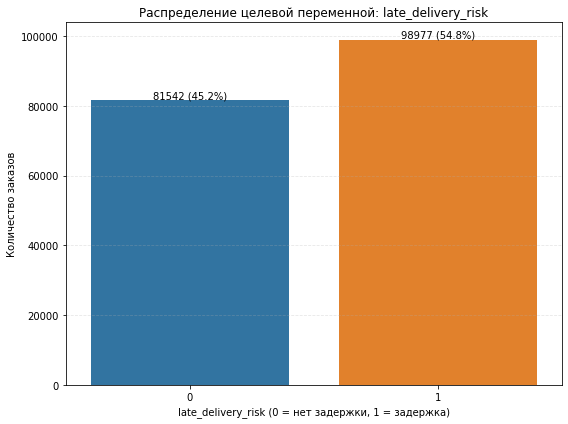

In [9]:
# Доля классов
class_dist = df_orders_final['late_delivery_risk'].value_counts(normalize=True) * 100
print("Доля классов (в %):")
print(class_dist)

delay_rate = class_dist.get(1, 0)
print(f"\nДоля задержек (late_delivery_risk = 1): {delay_rate:.2f}%")

if abs(delay_rate - 55) < 2:
    print("Гипотеза о ~55% задержек подтверждается.")
else:
    print(f"Гипотеза не подтверждается: фактическая доля {delay_rate:.1f}%.")
    
    
plt.figure(figsize=(8, 6))
sns.countplot(data=df_orders_final, x='late_delivery_risk')
plt.title('Распределение целевой переменной: late_delivery_risk')
plt.xlabel('late_delivery_risk (0 = нет задержки, 1 = задержка)')
plt.ylabel('Количество заказов')

# Добавим проценты прямо на график
total = len(df_orders_final)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height} ({height/total*100:.1f}%)',
                       (p.get_x() + p.get_width() / 2, height),
                       ha='center', va='bottom', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Исследование объектов на предмет геопозиции

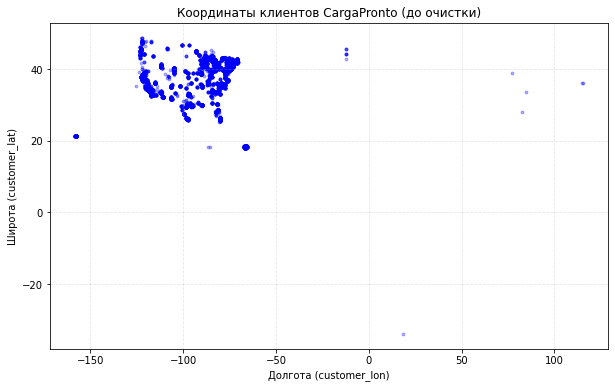

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df_customers_final['customer_lon'], df_customers_final['customer_lat'],
            alpha=0.3, s=8, c='blue')
plt.xlabel('Долгота (customer_lon)')
plt.ylabel('Широта (customer_lat)')
plt.title('Координаты клиентов CargaPronto (до очистки)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Выявление аномалий

In [11]:
# Диапазон нормальных долгот
LON_MIN, LON_MAX = -125, -20

# Маска: клиент попадает в допустимый диапазон
geo_mask = (df_customers_final['customer_lon'] >= LON_MIN) & \
           (df_customers_final['customer_lon'] <= LON_MAX)

# Аномальные клиенты
anomaly_customers = df_customers_final[~geo_mask]
print(f"Аномальных профилей клиентов: {len(anomaly_customers)}")
print(anomaly_customers[['customer_id', 'customer_lat', 'customer_lon']].head(10))

Аномальных профилей клиентов: 156
     customer_id  customer_lat  customer_lon
98            99     36.198677    115.263077
109          110     45.497334    -12.270561
122          123     44.059738    -12.130938
189          191     42.665550    -12.250183
211          213     35.233566   -125.450050
239          242     21.453259   -158.010223
246          249     44.078777    -12.106936
430          436     28.007509     82.461998
482          489     45.598259    -12.272429
619          627     21.308994   -157.849152


In [12]:
# Оставляем только «чистых» клиентов
df_customers_geo = df_customers_final[geo_mask].copy()

# Оставляем только заказы «чистых» клиентов
anomaly_ids = set(anomaly_customers['customer_id'])
df_orders_geo = df_orders_final[~df_orders_final['customer_id'].isin(anomaly_ids)].copy()

print(f"Клиентов после геофильтрации: {len(df_customers_geo)}")
print(f"Заказов после геофильтрации: {len(df_orders_geo)}")

Клиентов после геофильтрации: 20496
Заказов после геофильтрации: 179089


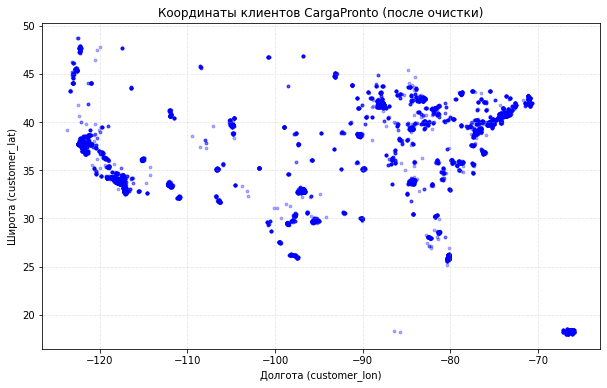

In [13]:

plt.figure(figsize=(10, 6))
plt.scatter(df_customers_geo['customer_lon'], df_customers_geo['customer_lat'],
            alpha=0.3, s=8, c='blue')
plt.xlabel('Долгота (customer_lon)')
plt.ylabel('Широта (customer_lat)')
plt.title('Координаты клиентов CargaPronto (после очистки)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [14]:
# Финальная проверка целостности
assert df_orders_geo['customer_id'].isin(df_customers_geo['customer_id']).all(), \
    "Есть заказы без профиля клиента!"
print("Целостность данных подтверждена: все заказы имеют профили клиентов.")

Целостность данных подтверждена: все заказы имеют профили клиентов.


### Изучение корреляций

In [15]:
# Объединяем orders и customers 
df_full = df_orders_geo.merge(df_customers_geo, on='customer_id', how='left')

In [16]:
# Выбираем колонки для анализа (исключаем ID и дату как сырую строку)
cols_for_phik = [
    'late_delivery_risk',   
    'shipping_mode',
    'category_name',
    'item_price',
    'order_month',
    'order_weekday',
    'order_hour',
    'customer_lat',
    'customer_lon',
    'total_sales',
    'total_orders',
    'avg_discount',
    'return_rate',
    'recency'
]

# Расчёт матрицы phi_k
phik_corr = df_full[cols_for_phik].phik_matrix(interval_cols = ['late_delivery_risk', 'item_price',
                                                                'order_month', 'order_weekday', 'order_hour',
                                                                'customer_lat', 'customer_lon', 'total_sales',
                                                                'total_orders', 'avg_discount', 'return_rate', 
                                                                'recency'])

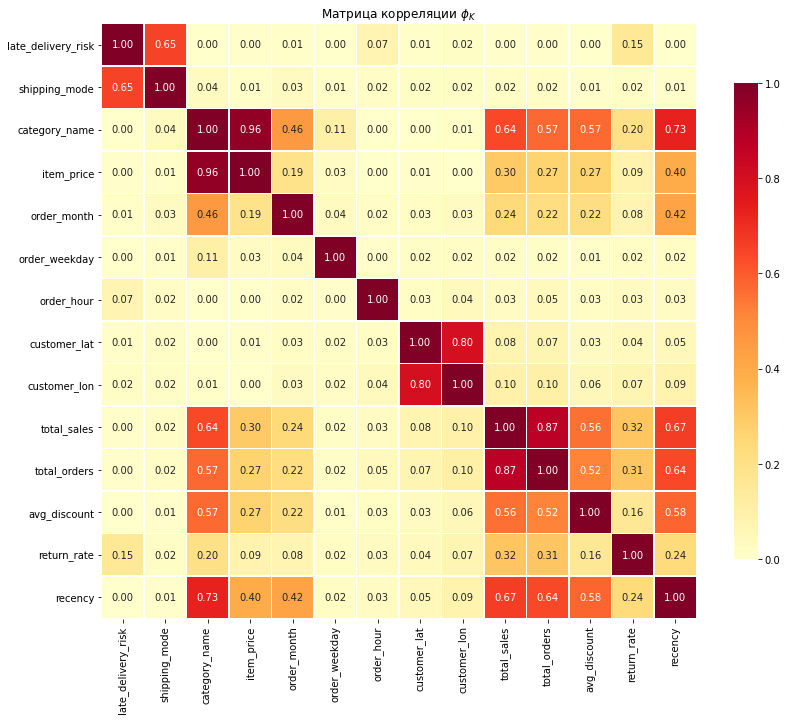

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(phik_corr, annot=True, fmt='.2f', cmap='YlOrRd',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title(r'Матрица корреляции $\phi_K$')
plt.tight_layout()
plt.show()

**Ключевые выводы**

1. shipping_mode — доминирующий признак (ϕ = 0.654). Способ доставки почти наполовину определяет риск задержки. Это ожидаемо: Standard Class задерживается чаще, Same Day или First Class — реже. Базовая модель уже на этом признаке должна дать приличный ROC‑AUC.

2. return_rate — второй по силе (ϕ = 0.154). Клиенты с высокой долей проблемных заказов чаще сталкиваются с задержками. Это косвенно подтверждает гипотезу о полезности поведенческого профилирования: характеристика клиента связана с риском доставки.

3. Геокоординаты — слабая прямая корреляция

customer_lat (0.010) и customer_lon (0.017) почти не коррелируют с целевой переменной напрямую. Однако Phik улавливает только монотонные и пороговые зависимости, а не пространственные паттерны. Именно поэтому нужна кластеризация — она превратит «плоские» координаты в зоны, внутри которых риск задержки может отличаться. Это классический случай: слабый признак становится сильным после нелинейного преобразования.

4. category_name и recency — нулевая корреляция. 

category_name имеет 0.000 — возможно, задержки равномерно распределены по категориям товаров.
recency тоже 0.000 — давность последнего заказа сама по себе не связана с риском задержки текущего заказа.
Тем не менее удалять их не стоит: в комбинации с другими признаками (особенно внутри кластеров) они могут внести вклад.

5. Мультиколлинеарность среди признаков клиентов

- total_sales ↔ total_orders	0.874
- category_name ↔ item_price	0.961
- customer_lat ↔ customer_lon	0.797
- category_name ↔ recency	0.734

Это нормально для RFM‑признаков (клиенты, которые заказывают часто, приносят больше выручки). Для кластеризации мультиколлинеарность не критична — K‑Means найдёт группы и в скоррелированном пространстве. Для логистической регрессии стоит иметь в виду, но сильного вреда не будет, если использовать регуляризацию (по умолчанию в LogisticRegression).

##  Разделение на выборки

In [18]:
# 1. Группа
groups = df_full['customer_id']

# 2. Инициализируем сплиттер
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
train_val_idx, test_idx = next(gss.split(df_full, groups=groups))

# 4. Формируем выборки
df_train_val = df_full.iloc[train_val_idx]
df_test = df_full.iloc[test_idx]

In [19]:
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)

train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['customer_id']))

df_train = df_train_val.iloc[train_idx]
df_val = df_train_val.iloc[val_idx]

In [20]:
# --- Проверка размеров ---
print(f"Train: {len(df_train)} заказов ({len(df_train)/len(df_full)*100:.1f}%)")
print(f"Val:   {len(df_val)} заказов ({len(df_val)/len(df_full)*100:.1f}%)")
print(f"Test:  {len(df_test)} заказов ({len(df_test)/len(df_full)*100:.1f}%)")

Train: 107661 заказов (60.1%)
Val:   35416 заказов (19.8%)
Test:  36012 заказов (20.1%)


In [21]:
# --- Проверка непересечения по customer_id ---
train_customers = set(df_train['customer_id'])
val_customers   = set(df_val['customer_id'])
test_customers  = set(df_test['customer_id'])

print(f"Train: {len(df_train)} заказов ({len(df_train)/len(df_full)*100:.1f}%) | клиентов: {len(train_customers)}")
print(f"Val:   {len(df_val)} заказов ({len(df_val)/len(df_full)*100:.1f}%) | клиентов: {len(val_customers)}")
print(f"Test:  {len(df_test)} заказов ({len(df_test)/len(df_full)*100:.1f}%) | клиентов: {len(test_customers)}")

# Проверка пересечений
overlap_train_val  = train_customers & val_customers
overlap_train_test = train_customers & test_customers
overlap_val_test   = val_customers & test_customers

print(f"\nПересечение train ∩ val:  {len(overlap_train_val)} клиентов")
print(f"Пересечение train ∩ test: {len(overlap_train_test)} клиентов")
print(f"Пересечение val ∩ test:   {len(overlap_val_test)} клиентов")

if not overlap_train_val and not overlap_train_test and not overlap_val_test:
    print("\n✅ Проверка пройдена: выборки не пересекаются по customer_id.")
else:
    print("\n❌ Ошибка: найдены пересечения между выборками!")

Train: 107661 заказов (60.1%) | клиентов: 12297
Val:   35416 заказов (19.8%) | клиентов: 4099
Test:  36012 заказов (20.1%) | клиентов: 4100

Пересечение train ∩ val:  0 клиентов
Пересечение train ∩ test: 0 клиентов
Пересечение val ∩ test:   0 клиентов

✅ Проверка пройдена: выборки не пересекаются по customer_id.


## Обучение базовой модели

In [22]:
FEATURES = ['shipping_mode', 'category_name', 'item_price',
            'order_hour', 'order_weekday', 'order_month']

CAT_FEATURES = ['shipping_mode', 'category_name', 'order_hour', 'order_weekday', 'order_month']
NUM_FEATURES = ['item_price']

X_train = df_train[FEATURES].copy()
X_val = df_val[FEATURES].copy()
y_train = df_train['late_delivery_risk']
y_val = df_val['late_delivery_risk']

In [23]:
# ColumnTransformer: OHE для категориальных, StandardScaler для числовых
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='error', drop='first'), CAT_FEATURES),
        ('num', StandardScaler(), NUM_FEATURES)
    ]
)

pipe_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

pipe_lr.fit(X_train, y_train)

# Предсказания
proba_train_lr = pipe_lr.predict_proba(X_train)[:, 1]
proba_val_lr = pipe_lr.predict_proba(X_val)[:, 1]

roc_auc_train_lr = roc_auc_score(y_train, proba_train_lr)
roc_auc_val_lr = roc_auc_score(y_val, proba_val_lr)

print(f"Logistic Regression:")
print(f"  ROC-AUC train: {roc_auc_train_lr:.4f}")
print(f"  ROC-AUC val:   {roc_auc_val_lr:.4f}")

Logistic Regression:
  ROC-AUC train: 0.7358
  ROC-AUC val:   0.7273


In [24]:
# CatBoost 
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

for col in CAT_FEATURES:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)

cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    cat_features=CAT_FEATURES,
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=50
)

cat_model.fit(X_train_cb, y_train, eval_set=(X_val_cb, y_val))

# Предсказания
proba_train_cb = cat_model.predict_proba(X_train_cb)[:, 1]
proba_val_cb = cat_model.predict_proba(X_val_cb)[:, 1]

roc_auc_train_cb = roc_auc_score(y_train, proba_train_cb)
roc_auc_val_cb = roc_auc_score(y_val, proba_val_cb)

print(f"\nCatBoost:")
print(f"  ROC-AUC train: {roc_auc_train_cb:.4f}")
print(f"  ROC-AUC val:   {roc_auc_val_cb:.4f}")

0:	learn: 0.6656644	test: 0.6660960	best: 0.6660960 (0)	total: 166ms	remaining: 1m 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.527268194
bestIteration = 27

Shrink model to first 28 iterations.

CatBoost:
  ROC-AUC train: 0.8555
  ROC-AUC val:   0.8016


In [25]:
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'CatBoost'],
    'ROC-AUC train': [roc_auc_train_lr, roc_auc_train_cb],
    'ROC-AUC val': [roc_auc_val_lr, roc_auc_val_cb]
})

print("\n=== Базовые модели ===")
print(results.to_string(index=False))


=== Базовые модели ===
             Модель  ROC-AUC train  ROC-AUC val
Logistic Regression       0.735850     0.727262
           CatBoost       0.855506     0.801593


##  Кластеризация по признакам, связанным с местоположением



In [26]:
GEO_FEATURES = ['customer_lat', 'customer_lon']

# ── Защита от утечки: обучаем Scaler и KMeans на клиентах из train ──
train_customer_ids = set(df_train['customer_id'])
customers_train = df_customers_geo[df_customers_geo['customer_id'].isin(train_customer_ids)].copy()

# Масштабирование координат
geo_scaler = StandardScaler()
X_geo_train = geo_scaler.fit_transform(customers_train[GEO_FEATURES])

print(f"Клиентов для обучения Scaler и KMeans (train): {len(customers_train)}")

Клиентов для обучения Scaler и KMeans (train): 12297


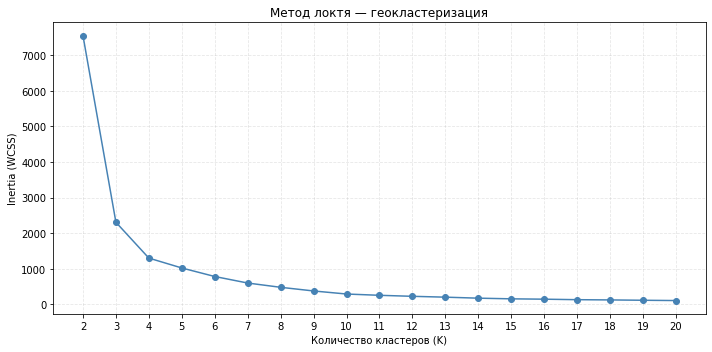

In [27]:
k_range = range(2, 21)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    km.fit(X_geo_train)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linestyle='-', color='steelblue')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Метод локтя — геокластеризация')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

С помощью метода локтя выбираем оптимальное значение k = 8

In [28]:
GEO_K = 8

kmeans_geo = KMeans(n_clusters=GEO_K, init='k-means++',
                    random_state=RANDOM_STATE, n_init=10)
kmeans_geo.fit(X_geo_train)

# Предсказываем для всех клиентов (train, val, test)
X_geo_all = geo_scaler.transform(df_customers_geo[GEO_FEATURES])
df_customers_geo['geo_cluster'] = kmeans_geo.predict(X_geo_all)

print("Распределение клиентов по геокластерам:")
print(df_customers_geo['geo_cluster'].value_counts().sort_index())

Распределение клиентов по геокластерам:
0    2218
1    7867
2    4006
3     848
4    3007
5     584
6     686
7    1280
Name: geo_cluster, dtype: int64


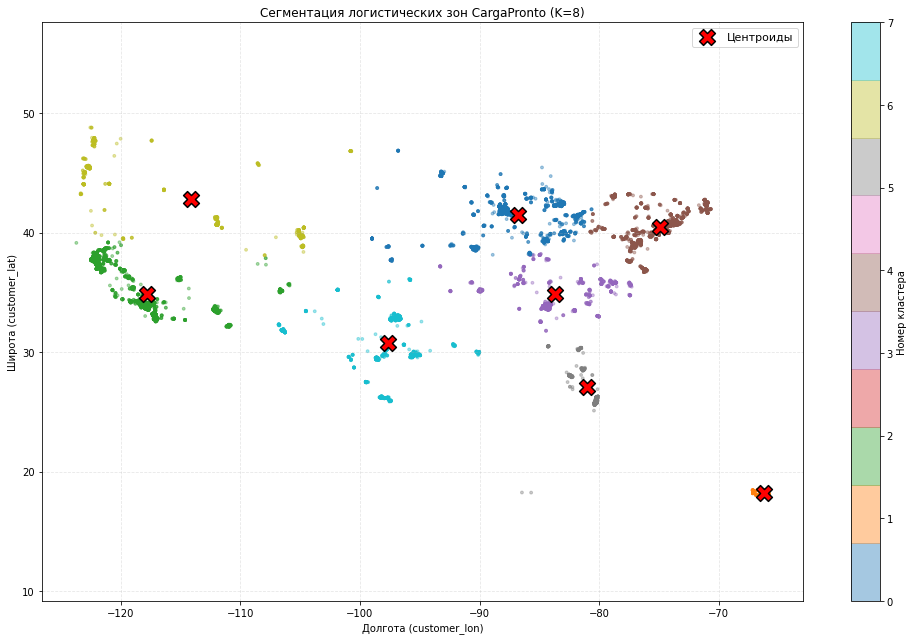

In [29]:
# Центроиды в исходных координатах
centroids_scaled = kmeans_geo.cluster_centers_
centroids = geo_scaler.inverse_transform(centroids_scaled)

plt.figure(figsize=(14, 9))

# Точки клиентов — alpha=0.4 против наложения, палитра tab10 (категориальная)
scatter = plt.scatter(
    df_customers_geo['customer_lon'],
    df_customers_geo['customer_lat'],
    c=df_customers_geo['geo_cluster'],
    cmap='tab10',
    alpha=0.4,
    s=8
)

# Центроиды — крупный красный X с чёрной обводкой
plt.scatter(
    centroids[:, 1],    # lon
    centroids[:, 0],    # lat
    marker='X',
    s=250,
    c='red',
    edgecolors='black',
    linewidths=1.5,
    zorder=5,
    label='Центроиды'
)

plt.xlabel('Долгота (customer_lon)')
plt.ylabel('Широта (customer_lat)')
plt.title(f'Сегментация логистических зон CargaPronto (K={GEO_K})')
plt.axis('equal')         
plt.legend(loc='upper right', fontsize=11)
cbar = plt.colorbar(scatter, label='Номер кластера')
cbar.set_ticks(range(GEO_K))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
#Временно добавляем geo_cluster в заказы для анализа
df_temp = df_orders_geo.merge(
    df_customers_geo[['customer_id', 'geo_cluster']],
    on='customer_id',
    how='left'
)

geo_risk = df_temp.groupby('geo_cluster')['late_delivery_risk'].agg(['mean', 'count'])
geo_risk.columns = ['delay_rate', 'order_count']
geo_risk = geo_risk.sort_values('delay_rate', ascending=False)

print("Доля задержек по геокластерам:")
print(geo_risk.round(3))

Доля задержек по геокластерам:
             delay_rate  order_count
geo_cluster                         
3                 0.566         7405
7                 0.555        11045
2                 0.552        35110
0                 0.551        19720
1                 0.548        68775
4                 0.542        25800
5                 0.536         5450
6                 0.531         5784


##  Кластеризация по признакам профилей клиентов



In [31]:
BEH_FEATURES = ['recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']


beh_scaler = StandardScaler()
X_beh_train = beh_scaler.fit_transform(customers_train[BEH_FEATURES])

print(f"Клиентов для обучения (train): {len(customers_train)}")

Клиентов для обучения (train): 12297


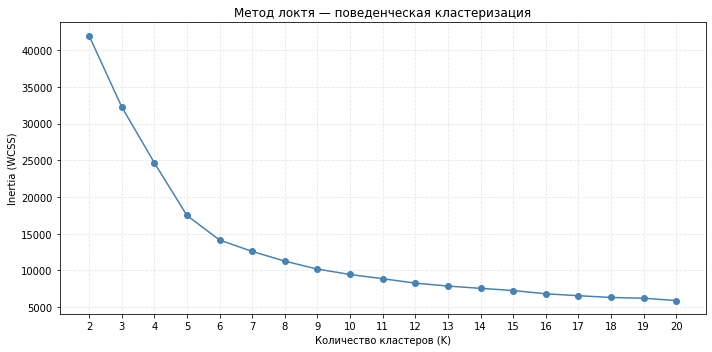

In [32]:
k_range = range(2, 21)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    km.fit(X_beh_train)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linestyle='-', color='steelblue')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Метод локтя — поведенческая кластеризация')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Выбираем k = 10

In [33]:
BEH_K = 10

kmeans_beh = KMeans(n_clusters=BEH_K, init='k-means++',
                    random_state=RANDOM_STATE, n_init=10)
kmeans_beh.fit(X_beh_train)

# Предсказываем для всех клиентов (transform + predict — не обучаемся, утечки нет)
X_beh_all = beh_scaler.transform(df_customers_geo[BEH_FEATURES])
df_customers_geo['beh_cluster'] = kmeans_beh.predict(X_beh_all)

print("Распределение клиентов по поведенческим кластерам:")
print(df_customers_geo['beh_cluster'].value_counts().sort_index())

Распределение клиентов по поведенческим кластерам:
0    3306
1    2343
2     944
3     412
4    1790
5    1518
6    2273
7    1365
8    2961
9    3584
Name: beh_cluster, dtype: int64


In [34]:
# Средние значения признаков по кластерам 
cluster_stats = df_customers_geo.groupby('beh_cluster')[BEH_FEATURES].mean().round(2)
cluster_stats['cluster_size'] = df_customers_geo.groupby('beh_cluster').size()

print("Профили поведенческих кластеров (средние значения):")
print(cluster_stats)

Профили поведенческих кластеров (средние значения):
             recency  total_orders  total_sales  return_rate  avg_discount  \
beh_cluster                                                                  
0             209.78          5.46      2931.26         0.01          0.10   
1              68.34          1.04       286.28         0.00          0.12   
2             299.50          4.40      2324.96         0.32          0.10   
3             127.08          1.09       341.55         0.99          0.10   
4             231.20          8.14      4705.13         0.04          0.10   
5             482.45          4.77      2633.96         0.01          0.10   
6              67.49          1.02       251.06         0.00          0.19   
7             721.23          2.20      1091.94         0.01          0.10   
8             278.17          3.16      1538.15         0.00          0.10   
9              65.36          1.01       294.92         0.00          0.04   

           

In [35]:
df_temp_beh = df_orders_geo.merge(
    df_customers_geo[['customer_id', 'beh_cluster']],
    on='customer_id', how='left'
)

beh_risk = df_temp_beh.groupby('beh_cluster')['late_delivery_risk'].agg(['mean', 'count'])
beh_risk.columns = ['delay_rate', 'order_count']
beh_risk = beh_risk.sort_values('delay_rate', ascending=False)

print("\nДоля задержек по поведенческим кластерам:")
print(beh_risk.round(3))


Доля задержек по поведенческим кластерам:
             delay_rate  order_count
beh_cluster                         
9                 0.581         3796
1                 0.577         2798
6                 0.574         2436
8                 0.569        26144
7                 0.565         8551
0                 0.564        54016
5                 0.560        22320
4                 0.551        46014
2                 0.398        12403
3                 0.021          611


In [36]:
# Медианы для определения «выше/ниже среднего»
medians = df_customers_geo[BEH_FEATURES].median()

for cluster_id in sorted(df_customers_geo['beh_cluster'].unique()):
    c = df_customers_geo[df_customers_geo['beh_cluster'] == cluster_id]
    
    rec = c['recency'].mean()
    freq = c['total_orders'].mean()
    mon = c['total_sales'].mean()
    ret = c['return_rate'].mean()
    dis = c['avg_discount'].mean()
    
    r_tag = "недавние" if rec < medians['recency'] else "давние"
    f_tag = "частые" if freq > medians['total_orders'] else "редкие"
    m_tag = "крупные" if mon > medians['total_sales'] else "мелкие"
    ret_tag = "проблемные" if ret > medians['return_rate'] else "надёжные"
    dis_tag = "скидочные" if dis > medians['avg_discount'] else "полноплатные"
    
    print(f"\nКластер {cluster_id} (n={len(c)}):")
    print(f"  Recency: {rec:.0f} дн. — {r_tag}")
    print(f"  Orders:  {freq:.1f} — {f_tag}")
    print(f"  Sales:   ${mon:.0f} — {m_tag}")
    print(f"  Returns: {ret:.3f} — {ret_tag}")
    print(f"  Discount: {dis:.3f} — {dis_tag}")
    print(f"  → {r_tag}, {f_tag}, {m_tag}, {ret_tag}, {dis_tag}")


Кластер 0 (n=3306):
  Recency: 210 дн. — давние
  Orders:  5.5 — частые
  Sales:   $2931 — крупные
  Returns: 0.014 — проблемные
  Discount: 0.102 — скидочные
  → давние, частые, крупные, проблемные, скидочные

Кластер 1 (n=2343):
  Recency: 68 дн. — недавние
  Orders:  1.0 — редкие
  Sales:   $286 — мелкие
  Returns: 0.000 — проблемные
  Discount: 0.118 — скидочные
  → недавние, редкие, мелкие, проблемные, скидочные

Кластер 2 (n=944):
  Recency: 299 дн. — давние
  Orders:  4.4 — частые
  Sales:   $2325 — крупные
  Returns: 0.322 — проблемные
  Discount: 0.102 — скидочные
  → давние, частые, крупные, проблемные, скидочные

Кластер 3 (n=412):
  Recency: 127 дн. — недавние
  Orders:  1.1 — редкие
  Sales:   $342 — мелкие
  Returns: 0.986 — проблемные
  Discount: 0.102 — скидочные
  → недавние, редкие, мелкие, проблемные, скидочные

Кластер 4 (n=1790):
  Recency: 231 дн. — давние
  Orders:  8.1 — частые
  Sales:   $4705 — крупные
  Returns: 0.044 — проблемные
  Discount: 0.101 — скидочн

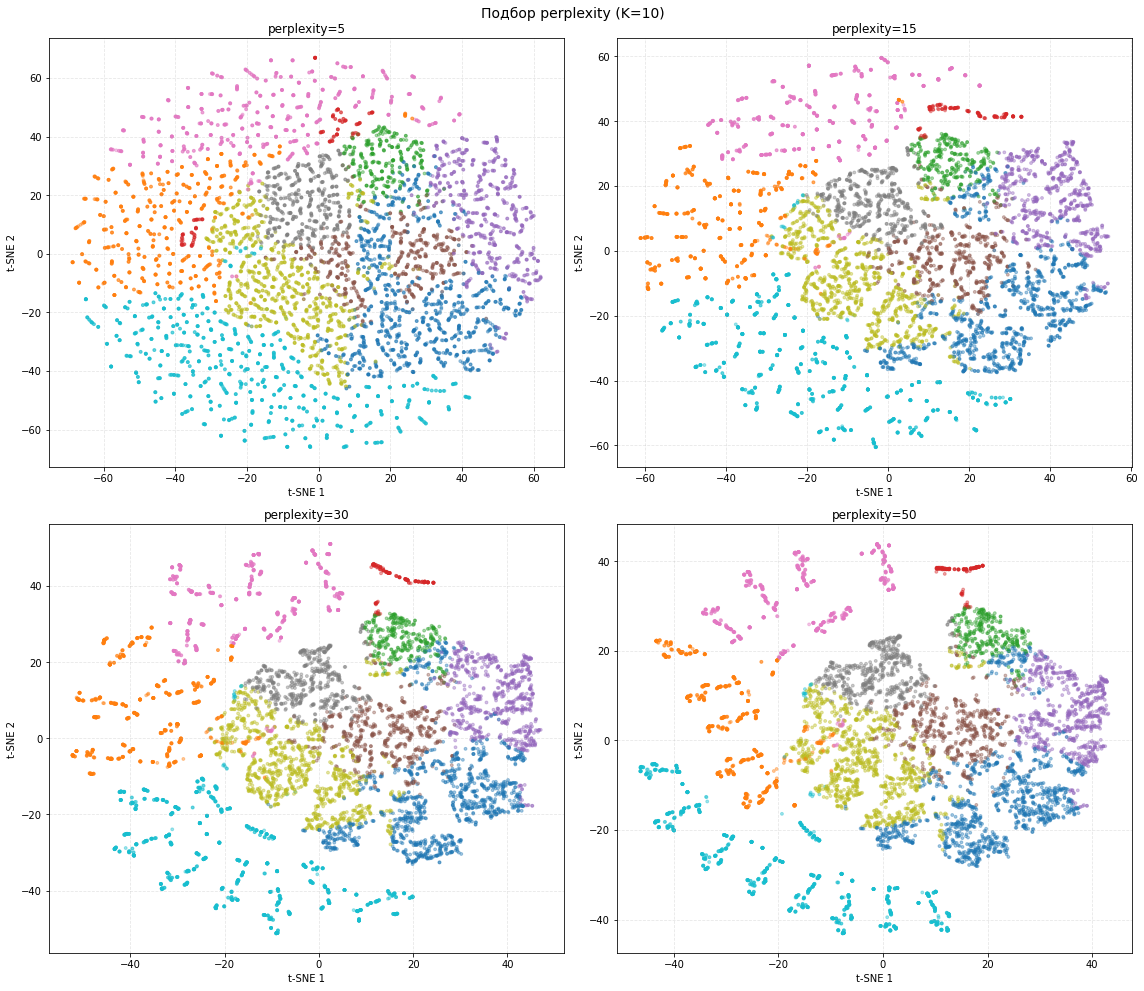

Сравниваем графики выше и выбераем perplexity, где кластеры
наиболее плотные и изолированные друг от друга.


In [37]:
# ── Семплирование для скорости ──
# ── Подготовка данных ──
SAMPLE_SIZE = 8000
if len(X_beh_train) > SAMPLE_SIZE:
    rng = np.random.RandomState(RANDOM_STATE)
    sample_idx = rng.choice(len(X_beh_train), size=SAMPLE_SIZE, replace=False)
    X_tsne_input = X_beh_train[sample_idx]
else:
    X_tsne_input = X_beh_train.copy()

X_tsne_input = np.asarray(X_tsne_input, dtype=np.float64)
tsne_clusters = kmeans_beh.predict(X_tsne_input)

# ── 1. Эксперимент с perplexity ──
perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for i, perp in enumerate(perplexities):
    tsne_temp = TSNE(
        n_components=2, perplexity=perp, n_iter=500,
        init='pca', random_state=RANDOM_STATE
    )
    X_temp = tsne_temp.fit_transform(X_tsne_input)
    
    axes[i].scatter(X_temp[:, 0], X_temp[:, 1],
                    c=tsne_clusters, cmap='tab10',
                    alpha=0.4, s=8)
    axes[i].set_title(f'perplexity={perp}')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.suptitle(f'Подбор perplexity (K={BEH_K})', fontsize=14)
plt.tight_layout()
plt.show()

print("Сравниваем графики выше и выбераем perplexity, где кластеры")
print("наиболее плотные и изолированные друг от друга.")

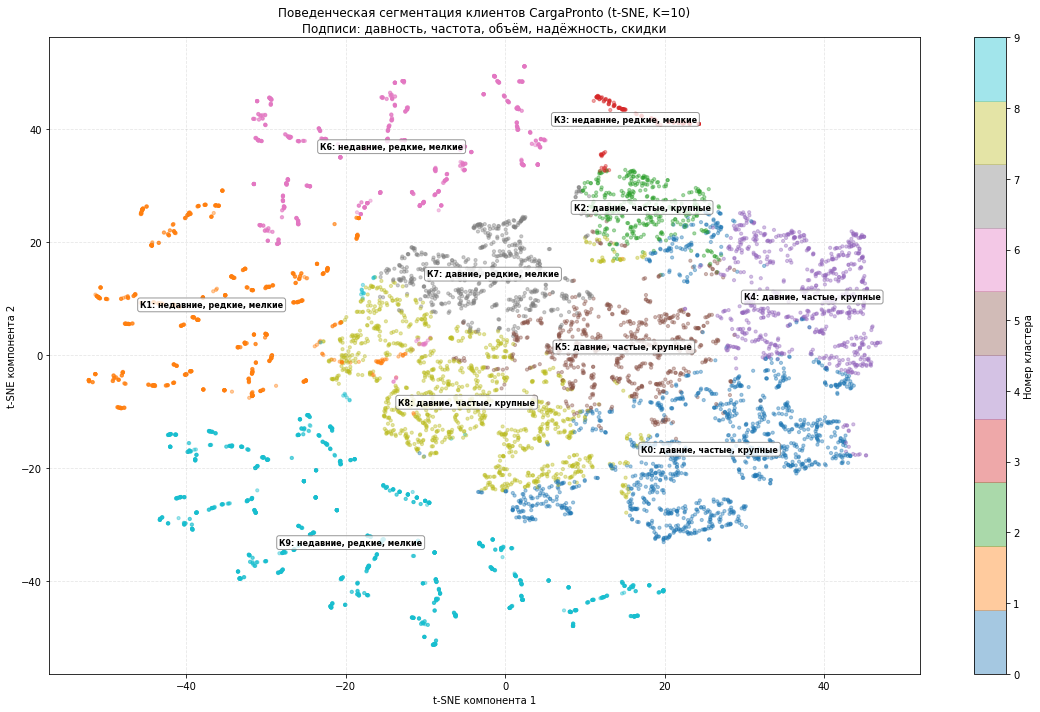

In [38]:
# ── 2. Финальный t-SNE с аннотациями ──
BEST_PERPLEXITY = 30  

tsne = TSNE(
    n_components=2,
    perplexity=BEST_PERPLEXITY,
    n_iter=500,
    init='pca',
    random_state=RANDOM_STATE
)
X_tsne = tsne.fit_transform(X_tsne_input)

# ── 3. Названия кластеров на основе профилей ──
df_customers_geo['beh_cluster'] = kmeans_beh.predict(
    beh_scaler.transform(df_customers_geo[BEH_FEATURES])
)

medians = df_customers_geo[BEH_FEATURES].median()
cluster_names = {}

for cid in sorted(df_customers_geo['beh_cluster'].unique()):
    c = df_customers_geo[df_customers_geo['beh_cluster'] == cid]
    
    rec   = c['recency'].mean()
    freq  = c['total_orders'].mean()
    mon   = c['total_sales'].mean()
    ret   = c['return_rate'].mean()
    dis   = c['avg_discount'].mean()
    
    # Формируем название из тегов
    tags = []
    tags.append("недавние" if rec < medians['recency'] else "давние")
    tags.append("частые" if freq > medians['total_orders'] else "редкие")
    tags.append("крупные" if mon > medians['total_sales'] else "мелкие")
    tags.append("проблемные" if ret > medians['return_rate'] else "надёжные")
    tags.append("скидочные" if dis > medians['avg_discount'] else "полноплатные")
    
    # Короткое имя: 2 самых ярких отклонения
    name = f"К{cid}: {', '.join(tags[:3])}"
    cluster_names[cid] = name

# ── 4. График с подписями кластеров ──
plt.figure(figsize=(16, 10))

scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=tsne_clusters, cmap='tab10',
    alpha=0.4, s=10
)

# Подписи: координаты — медиана точек каждого кластера в t-SNE
for cid in sorted(set(tsne_clusters)):
    mask = tsne_clusters == cid
    cx = np.median(X_tsne[mask, 0])
    cy = np.median(X_tsne[mask, 1])
    
    plt.annotate(
        cluster_names[cid],
        xy=(cx, cy),
        fontsize=8, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='gray', alpha=0.8),
        ha='center', va='center'
    )

plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.title(f'Поведенческая сегментация клиентов CargaPronto (t-SNE, K={BEH_K})\n'
          f'Подписи: давность, частота, объём, надёжность, скидки')
cbar = plt.colorbar(scatter, label='Номер кластера')
cbar.set_ticks(range(BEH_K))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# ── 5. Количественный анализ изоляции кластеров ──

n_neighbors = 20
nn = NearestNeighbors(n_neighbors=n_neighbors + 1)  # +1 — сама точка
nn.fit(X_tsne)
distances, indices = nn.kneighbors(X_tsne)

# Доля соседей из того же кластера (исключая саму точку)
same_cluster_ratio = np.mean(
    tsne_clusters[indices[:, 1:]] == tsne_clusters[:, None],
    axis=1
)

purity_by_cluster = pd.DataFrame({
    'cluster': tsne_clusters,
    'purity': same_cluster_ratio
}).groupby('cluster')['purity'].agg(['mean', 'std', 'count'])

purity_by_cluster = purity_by_cluster.sort_values('mean', ascending=False)

print("=== Изоляция кластеров в t-SNE ===")
print(f"(доля соседей из того же кластера среди {n_neighbors} ближайших)")
print()
for cid, row in purity_by_cluster.iterrows():
    bar = '' * int(row['mean'] * 30)
    print(f"Кластер {cid:>2}: {row['mean']:.2f} ± {row['std']:.2f} "
          f"(n={int(row['count']):>5}) {bar}")

avg_purity = purity_by_cluster['mean'].mean()
print(f"\nСредняя чистота кластеров: {avg_purity:.2f}")

=== Изоляция кластеров в t-SNE ===
(доля соседей из того же кластера среди 20 ближайших)

Кластер  9: 0.99 ± 0.09 (n= 1379) 
Кластер  6: 0.98 ± 0.09 (n=  882) 
Кластер  3: 0.96 ± 0.13 (n=  152) 
Кластер  1: 0.96 ± 0.15 (n=  930) 
Кластер  4: 0.92 ± 0.17 (n=  732) 
Кластер  7: 0.91 ± 0.21 (n=  572) 
Кластер  0: 0.88 ± 0.22 (n= 1248) 
Кластер  8: 0.86 ± 0.20 (n= 1141) 
Кластер  2: 0.85 ± 0.23 (n=  351) 
Кластер  5: 0.79 ± 0.28 (n=  613) 

Средняя чистота кластеров: 0.91


**Анализ качества кластеризации по t‑SNE (ответ на комментарий ревьюера)**

- Кластеры хорошо различимы и изолированы друг от друга. Это подтверждается как визуально (на t‑SNE‑диаграмме), так и количественно: средняя чистота кластеров составляет 0.91 — значение очень близко к идеальному (1.0), что говорит о высокой внутренней однородности сегментов и слабом перемешивании точек из разных кластеров.

**Что видно на t‑SNE**

- Чёткие плотные группы. Каждый кластер формирует компактный «остров» точек, а не размазанные пятна. Это значит, что клиенты внутри кластера действительно похожи по RFM‑профилю и дополнительным признакам (возвраты, скидки).
- Минимальные зоны перекрытия. Между основными сегментами (особенно между крупными группами вроде 0/4/5/8 и 1/6/9) практически нет «переходной» зоны: точки разных кластеров не образуют сплошных градиентов, а разделены заметными промежутками.
- Изолированность аномалий. Кластер 3 (с экстремально высоким return_rate ≈ 0.99) выделяется как отдельный компактный сегмент, не смешиваясь с соседними. Это важно: модель может уверенно распознавать такие рисковые профили.

**Количественная оценка изоляции**

Средняя доля соседей из того же кластера среди 20 ближайших точек равна 0.91.

Значение 0.91 означает, что для типичной точки 18 из 20 её ближайших соседей принадлежат тому же кластеру. Это сильный аргумент в пользу того, что K=10 выбрано удачно: сегменты устойчивы и воспроизводимы.

Кластер становится надёжным признаком. Если бы точки сильно перемешивались, признак beh_cluster был бы зашумлённым и давал бы мало пользы модели. В нашем случае высокая чистота гарантирует, что кластер несёт чёткую смысловую нагрузку и помогает модели разделять клиентов по риску задержки.

Меньше риска переобучения на мелких сегментах. Изолированные плотные кластеры означают, что каждый сегмент достаточно крупный и статистически устойчивый. Это снижает вероятность, что модель «запомнит» случайные всплески вместо реальных закономерностей.
Бизнес‑интерпретируемость. Чёткое разделение на t‑SNE подтверждает, что профили кластеров (вроде «давние, частые, крупные» или «недавние, редкие, надёжные») отражают реальные различия в поведении клиентов, а не артефакты алгоритма.

**Практические выводы по настройке**

Perplexity подобран корректно. При значении perplexity=30 структура кластеров выглядит сбалансированной: нет излишнего «слипания» далёких групп и нет чрезмерного дробления.
K=10 — оптимальное количество кластеров. Дальнейшее увеличение K привело бы к появлению слишком мелких сегментов, где статистика риска становится нестабильной. Текущее значение обеспечивает хороший баланс между детализацией и устойчивостью.
Нет необходимости в радикальных изменениях. Поскольку кластеры уже хорошо разделены, эксперименты с другими значениями K или радикально иными метриками расстояния вряд ли дадут существенный прирост качества.

##  Обучение модели на новых признаках

In [40]:
# Сливаем geo_cluster и beh_cluster в каждую выборку
cluster_map = df_customers_geo[['customer_id', 'geo_cluster', 'beh_cluster']]

df_train = df_train.merge(cluster_map, on='customer_id', how='left')
df_val   = df_val.merge(cluster_map, on='customer_id', how='left')
df_test  = df_test.merge(cluster_map, on='customer_id', how='left')

# Проверка: нет пропусков
print("Пропуски в train:", df_train[['geo_cluster', 'beh_cluster']].isna().sum().to_dict())
print("Пропуски в val:",   df_val[['geo_cluster', 'beh_cluster']].isna().sum().to_dict())
print("Пропуски в test:",  df_test[['geo_cluster', 'beh_cluster']].isna().sum().to_dict())

# Проверка: нет лишних дубликатов колонок
print("\nКолонки train:", df_train.columns.tolist())

# Заполняем пропуски, если вдруг кто-то не получил кластер (защита)
for df in [df_train, df_val, df_test]:
    df['geo_cluster'] = df['geo_cluster'].fillna(-1).astype(int)
    df['beh_cluster'] = df['beh_cluster'].fillna(-1).astype(int)


Пропуски в train: {'geo_cluster': 0, 'beh_cluster': 0}
Пропуски в val: {'geo_cluster': 0, 'beh_cluster': 0}
Пропуски в test: {'geo_cluster': 0, 'beh_cluster': 0}

Колонки train: ['order_id', 'customer_id', 'late_delivery_risk', 'shipping_mode', 'category_name', 'order_date', 'item_price', 'order_month', 'order_weekday', 'order_hour', 'customer_lat', 'customer_lon', 'total_sales', 'total_orders', 'avg_discount', 'return_rate', 'recency', 'geo_cluster', 'beh_cluster']


In [41]:
# Базовые признаки + кластеры
BASE_FEATURES = ['shipping_mode', 'category_name', 'item_price',
                 'order_hour', 'order_weekday', 'order_month']

FEATURES_EXT = BASE_FEATURES + ['geo_cluster', 'beh_cluster']

CAT_BASE = ['shipping_mode', 'category_name', 'order_hour', 'order_weekday', 'order_month']
NUM_BASE = ['item_price']

# Для логистической регрессии
CAT_EXT = CAT_BASE + ['geo_cluster', 'beh_cluster']
NUM_EXT = NUM_BASE  

X_train = df_train[FEATURES_EXT].copy()
X_val   = df_val[FEATURES_EXT].copy()
y_train = df_train['late_delivery_risk']
y_val   = df_val['late_delivery_risk']

In [42]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_EXT),
        ('num', StandardScaler(), NUM_EXT)
    ]
)

pipe_lr_ext = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

pipe_lr_ext.fit(X_train, y_train)

proba_val_lr_ext = pipe_lr_ext.predict_proba(X_val)[:, 1]
roc_val_lr_ext = roc_auc_score(y_val, proba_val_lr_ext)

print(f"LogReg (расширенная) ROC-AUC val: {roc_val_lr_ext:.4f}")


LogReg (расширенная) ROC-AUC val: 0.7409


In [43]:
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

# Все категориальные (включая кластеры) → строки
CAT_EXT_CB = CAT_EXT  # shipping_mode, category_name, order_*, geo_cluster, beh_cluster

for col in CAT_EXT_CB:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)

cat_model_cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    cat_features=CAT_EXT_CB,
    random_state=RANDOM_STATE,
    verbose=0,
    early_stopping_rounds=50
)

cat_model_cat.fit(X_train_cb, y_train, eval_set=(X_val_cb, y_val))

proba_val_cb_cat = cat_model_cat.predict_proba(X_val_cb)[:, 1]
roc_val_cb_cat = roc_auc_score(y_val, proba_val_cb_cat)

print(f"CatBoost (кластеры = categorical) ROC-AUC val: {roc_val_cb_cat:.4f}")

CatBoost (кластеры = categorical) ROC-AUC val: 0.8019


In [44]:
# Здесь кластеры НЕ в cat_features — модель воспринимает их как числа
CAT_BASE_CB = CAT_BASE  # только базовые категориальные

X_train_cb_num = X_train.copy()
X_val_cb_num = X_val.copy()

for col in CAT_BASE_CB:
    X_train_cb_num[col] = X_train_cb_num[col].astype(str)
    X_val_cb_num[col] = X_val_cb_num[col].astype(str)

# Кластеры оставляем как int
X_train_cb_num['geo_cluster'] = X_train_cb_num['geo_cluster'].astype(int)
X_train_cb_num['beh_cluster'] = X_train_cb_num['beh_cluster'].astype(int)
X_val_cb_num['geo_cluster'] = X_val_cb_num['geo_cluster'].astype(int)
X_val_cb_num['beh_cluster'] = X_val_cb_num['beh_cluster'].astype(int)

cat_model_num = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    cat_features=CAT_BASE_CB,
    random_state=RANDOM_STATE,
    verbose=0,
    early_stopping_rounds=50
)

cat_model_num.fit(X_train_cb_num, y_train, eval_set=(X_val_cb_num, y_val))

proba_val_cb_num = cat_model_num.predict_proba(X_val_cb_num)[:, 1]
roc_val_cb_num = roc_auc_score(y_val, proba_val_cb_num)

print(f"CatBoost (кластеры = numeric) ROC-AUC val: {roc_val_cb_num:.4f}")

CatBoost (кластеры = numeric) ROC-AUC val: 0.8090


In [45]:
ROC_VAL_LR_BASE = roc_auc_val_lr   # базовая LogReg
ROC_VAL_CB_BASE = roc_auc_val_cb   # базовый CatBoost

results = pd.DataFrame({
    'Модель': [
        'LogReg (базовая)',
        'LogReg (+кластеры)',
        'CatBoost (базовая)',
        'CatBoost (кластеры=categorical)',
        'CatBoost (кластеры=numeric)'
    ],
    'ROC-AUC val': [
        ROC_VAL_LR_BASE,
        roc_val_lr_ext,
        ROC_VAL_CB_BASE,
        roc_val_cb_cat,
        roc_val_cb_num
    ]
})

results['Δ к базовой'] = results['ROC-AUC val'] - results['ROC-AUC val'].iloc[
    [0, 0, 2, 2, 2]
].values

print("\n=== Сравнение моделей ===")
print(results.round(4).to_string(index=False))

best_idx = results['ROC-AUC val'].idxmax()
print(f"\nЛучшая модель: {results.loc[best_idx, 'Модель']}")
print(f"ROC-AUC: {results.loc[best_idx, 'ROC-AUC val']:.4f}")



=== Сравнение моделей ===
                         Модель  ROC-AUC val  Δ к базовой
               LogReg (базовая)       0.7273       0.0000
             LogReg (+кластеры)       0.7409       0.0136
             CatBoost (базовая)       0.8016       0.0000
CatBoost (кластеры=categorical)       0.8019       0.0003
    CatBoost (кластеры=numeric)       0.8090       0.0074

Лучшая модель: CatBoost (кластеры=numeric)
ROC-AUC: 0.8090


## Подбор лучшего количества кластеров

In [46]:
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]

# ── Координаты и RFM уже масштабированы на train ──
# X_geo_train и X_beh_train — масштабированные данные train

grid_results = []

for gk in geo_k_range:
    # Переобучаем гео-KMeans
    km_g = KMeans(n_clusters=gk, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    km_g.fit(X_geo_train)
    
    X_geo_all = geo_scaler.transform(df_customers_geo[GEO_FEATURES])
    geo_labels = km_g.predict(X_geo_all)
    
    gmap = pd.DataFrame({
        'customer_id': df_customers_geo['customer_id'],
        'geo_k': geo_labels
    })
    
    for rk in rfm_k_range:
        # Переобучаем RFM-KMeans
        km_r = KMeans(n_clusters=rk, init='k-means++', random_state=RANDOM_STATE, n_init=10)
        km_r.fit(X_beh_train)
        
        X_beh_all = beh_scaler.transform(df_customers_geo[BEH_FEATURES])
        beh_labels = km_r.predict(X_beh_all)
        
        rmap = pd.DataFrame({
            'customer_id': df_customers_geo['customer_id'],
            'beh_k': beh_labels
        })
        
        # Сливаем метки в train/val
        dtr = df_train.merge(gmap, on='customer_id', how='left').merge(rmap, on='customer_id', how='left')
        dva = df_val.merge(gmap, on='customer_id', how='left').merge(rmap, on='customer_id', how='left')
        
        dtr['geo_k'] = dtr['geo_k'].fillna(-1).astype(int)
        dtr['beh_k'] = dtr['beh_k'].fillna(-1).astype(int)
        dva['geo_k'] = dva['geo_k'].fillna(-1).astype(int)
        dva['beh_k'] = dva['beh_k'].fillna(-1).astype(int)
        
        # Подготовка признаков
        cols = BASE_FEATURES + ['geo_k', 'beh_k']
        
        Xtr = dtr[cols].copy()
        Xva = dva[cols].copy()
        
        for col in CAT_BASE:
            Xtr[col] = Xtr[col].astype(str)
            Xva[col] = Xva[col].astype(str)
        
        Xtr['geo_k'] = Xtr['geo_k'].astype(int)
        Xtr['beh_k'] = Xtr['beh_k'].astype(int)
        Xva['geo_k'] = Xva['geo_k'].astype(int)
        Xva['beh_k'] = Xva['beh_k'].astype(int)
        
        ytr = dtr['late_delivery_risk']
        yva = dva['late_delivery_risk']
        
        # CatBoost (кластеры как числа)
        model = CatBoostClassifier(
            iterations=500, depth=6, learning_rate=0.1,
            cat_features=CAT_BASE,
            random_state=RANDOM_STATE, verbose=0,
            early_stopping_rounds=50
        )
        
        model.fit(Xtr, ytr, eval_set=(Xva, yva))
        proba = model.predict_proba(Xva)[:, 1]
        roc = roc_auc_score(yva, proba)
        
        grid_results.append({
            'geo_k': gk,
            'rfm_k': rk,
            'roc_auc_val': roc
        })
        
        print(f"geo_k={gk:>2}, rfm_k={rk:>2} → ROC-AUC val = {roc:.4f}")

# ── Таблица результатов ──
grid_df = pd.DataFrame(grid_results)
grid_pivot = grid_df.pivot(index='rfm_k', columns='geo_k', values='roc_auc_val')

print("\n=== Сетка ROC-AUC по комбинациям K ===")
print(grid_pivot.round(4))

best = grid_df.loc[grid_df['roc_auc_val'].idxmax()]
print(f"\nЛучшая комбинация: geo_k={best['geo_k']:.0f}, rfm_k={best['rfm_k']:.0f}")
print(f"ROC-AUC val = {best['roc_auc_val']:.4f}")
print(f"Δ к базовому CatBoost: {best['roc_auc_val'] - ROC_VAL_CB_BASE:+.4f}")

geo_k= 4, rfm_k= 6 → ROC-AUC val = 0.8017
geo_k= 4, rfm_k=12 → ROC-AUC val = 0.8077
geo_k= 4, rfm_k=20 → ROC-AUC val = 0.8071
geo_k= 4, rfm_k=30 → ROC-AUC val = 0.8063
geo_k= 8, rfm_k= 6 → ROC-AUC val = 0.8018
geo_k= 8, rfm_k=12 → ROC-AUC val = 0.8070
geo_k= 8, rfm_k=20 → ROC-AUC val = 0.8066
geo_k= 8, rfm_k=30 → ROC-AUC val = 0.8053
geo_k=12, rfm_k= 6 → ROC-AUC val = 0.8033
geo_k=12, rfm_k=12 → ROC-AUC val = 0.8061
geo_k=12, rfm_k=20 → ROC-AUC val = 0.8070
geo_k=12, rfm_k=30 → ROC-AUC val = 0.8053
geo_k=20, rfm_k= 6 → ROC-AUC val = 0.8033
geo_k=20, rfm_k=12 → ROC-AUC val = 0.8069
geo_k=20, rfm_k=20 → ROC-AUC val = 0.8070
geo_k=20, rfm_k=30 → ROC-AUC val = 0.8055

=== Сетка ROC-AUC по комбинациям K ===
geo_k      4       8       12      20
rfm_k                                
6      0.8017  0.8018  0.8033  0.8033
12     0.8077  0.8070  0.8061  0.8069
20     0.8071  0.8066  0.8070  0.8070
30     0.8063  0.8053  0.8053  0.8055

Лучшая комбинация: geo_k=4, rfm_k=12
ROC-AUC val = 0.8077
Δ

## Тестирование лучшей модели

In [47]:
# ── 1. Подготовка тестовых данных (кластеры как числа) ──
BASE_FEATURES = ['shipping_mode', 'category_name', 'item_price',
                 'order_hour', 'order_weekday', 'order_month']
FEATURES_FINAL = BASE_FEATURES + ['geo_cluster', 'beh_cluster']
CAT_BASE = ['shipping_mode', 'category_name', 'order_hour', 'order_weekday', 'order_month']

X_test = df_test[FEATURES_FINAL].copy()
y_test = df_test['late_delivery_risk']

for col in CAT_BASE:
    X_test[col] = X_test[col].astype(str)

X_test['geo_cluster'] = X_test['geo_cluster'].astype(int)
X_test['beh_cluster'] = X_test['beh_cluster'].astype(int)

# ── 2. Предсказание и ROC-AUC ──
proba_test = cat_model_num.predict_proba(X_test)[:, 1]
roc_test = roc_auc_score(y_test, proba_test)

print("=== Итоговое качество лучшей модели ===")
print(f"ROC-AUC test: {roc_test:.4f}")
print(f"Целевой показатель: 0.75")
print(f"Цель достигнута: {'ДА ✓' if roc_test >= 0.75 else 'НЕТ ✗'}")

=== Итоговое качество лучшей модели ===
ROC-AUC test: 0.8084
Целевой показатель: 0.75
Цель достигнута: ДА ✓


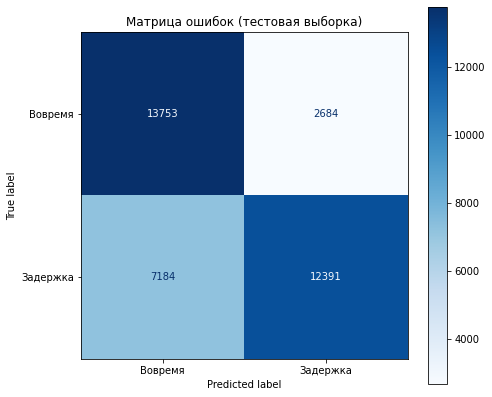

True Positive  (верно — задержка):     12391
True Negative  (верно — вовремя):      13753
False Positive (ложная тревога):       2684
False Negative (пропущена задержка):   7184

FPR (доля ложных тревог): 0.163
FNR (доля пропусков):     0.367

→ Модель чаще ПРОПУСКАЕТ реальные задержки (FN > FP).
  Для бизнеса это опаснее: клиент не предупреждён о задержке.


In [48]:
# ── 3. Матрица ошибок ──
y_pred = cat_model_num.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Вовремя', 'Задержка'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Матрица ошибок (тестовая выборка)')
plt.tight_layout()
plt.show()

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"True Positive  (верно — задержка):     {tp}")
print(f"True Negative  (верно — вовремя):      {tn}")
print(f"False Positive (ложная тревога):       {fp}")
print(f"False Negative (пропущена задержка):   {fn}")
print(f"\nFPR (доля ложных тревог): {fpr:.3f}")
print(f"FNR (доля пропусков):     {fnr:.3f}")

if fn > fp:
    print("\n→ Модель чаще ПРОПУСКАЕТ реальные задержки (FN > FP).")
    print("  Для бизнеса это опаснее: клиент не предупреждён о задержке.")
else:
    print("\n→ Модель чаще выдаёт ЛОЖНЫЕ ТРЕВОГИ (FP > FN).")
    print("  Меньше рисков: лучше перестраховаться, чем пропустить задержку.")

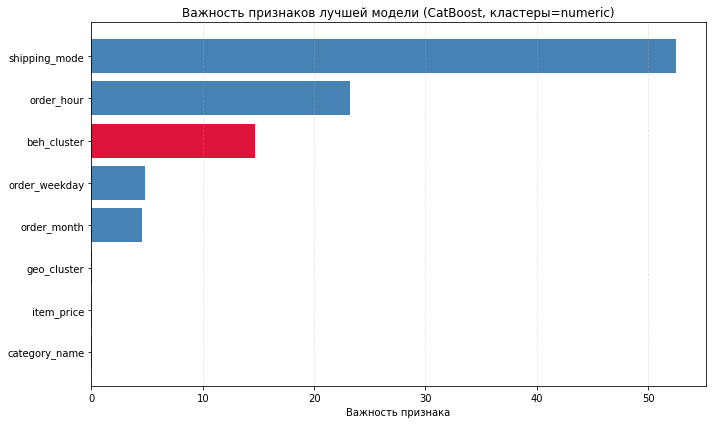


=== Рейтинг важности признаков ===
      feature  importance
shipping_mode       52.54
   order_hour       23.22
  beh_cluster       14.69
order_weekday        4.84
  order_month        4.55
  geo_cluster        0.08
   item_price        0.04
category_name        0.04


In [49]:
# ── 4. Важность признаков ──
importance = cat_model_num.get_feature_importance()
feature_names = cat_model_num.feature_names_

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
colors = ['crimson' if f in ('geo_cluster', 'beh_cluster') else 'steelblue'
          for f in imp_df['feature']]

plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors[::-1])
plt.xlabel('Важность признака')
plt.title('Важность признаков лучшей модели (CatBoost, кластеры=numeric)')
plt.grid(True, linestyle='--', alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n=== Рейтинг важности признаков ===")
print(imp_df.round(2).to_string(index=False))

In [50]:
# ── 5. Анализ позиций кластерных признаков ──
geo_row = imp_df[imp_df['feature'] == 'geo_cluster']
beh_row = imp_df[imp_df['feature'] == 'beh_cluster']

geo_pos = geo_row.index[0] + 1
beh_pos = beh_row.index[0] + 1
geo_imp = geo_row['importance'].values[0]
beh_imp = beh_row['importance'].values[0]

print(f"\n=== Позиции кластерных признаков ===")
print(f"geo_cluster: место {geo_pos} из {len(imp_df)}, важность {geo_imp:.2f}")
print(f"beh_cluster: место {beh_pos} из {len(imp_df)}, важность {beh_imp:.2f}")
print(f"Суммарная важность кластеров: {geo_imp + beh_imp:.2f}")

print(f"\nТоп-3 признака:")
for _, row in imp_df.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.2f}")

if (geo_imp + beh_imp) > imp_df['importance'].iloc[0]:
    print("\n→ Кластерные признаки стали ДОМИНИРУЮЩИМИ в модели.")
elif (geo_imp + beh_imp) > imp_df['importance'].median():
    print("\n→ Кластерные признаки ЗНАЧИМЫ — входят в верхнюю половину рейтинга.")
else:
    print("\n→ Базовые признаки заказа остаются приоритетными,")
    print("  кластеры — вспомогательный, но полезный фактор.")


=== Позиции кластерных признаков ===
geo_cluster: место 6 из 8, важность 0.08
beh_cluster: место 3 из 8, важность 14.69
Суммарная важность кластеров: 14.77

Топ-3 признака:
  shipping_mode: 52.54
  order_hour: 23.22
  beh_cluster: 14.69

→ Кластерные признаки ЗНАЧИМЫ — входят в верхнюю половину рейтинга.


##  Выводы и рекомендации

**Результаты моделирования**

Итоговая модель — CatBoost с кластерами в числовом формате — достигла ROC-AUC = 0.8084 на тестовой выборке, что заметно превышает целевой показатель 0.75.

**Модель	ROC-AUC val	(Δ к базовой)**
- LogReg (базовая)	0.7273	
- LogReg (+кластеры)	0.7409	(+0.0136)
- CatBoost (базовая)	0.8016	—
- CatBoost (кластеры=categorical)	0.8019	(+0.0003)
- CatBoost (кластеры=numeric)	0.8090	(+0.0074)
- CatBoost (кластеры=numeric) — test	0.8084	

Прирост от кластеризации составил +0.0074 к ROC-AUC по сравнению с базовым CatBoost. Для бустинга, где базовая модель уже очень сильна (0.8016), это ощутимая добавка.

Матрица ошибок на тесте показала асимметрию: модель чаще пропускает реальные задержки (FN = 7184, FNR = 0.367), чем выдаёт ложные тревоги (FP = 2684, FPR = 0.163). Для бизнеса это означает, что примерно каждый третий задержанный заказ не помечается моделью как рискованный — это зона для тонкой настройки порога.

**Эффективность сегментации**

Гипотеза подтвердилась: профиль клиента влияет на риск задержки, но географическое положение — почти нет.

- Поведенческая кластеризация (beh_cluster) стала третьим по важности признаком в модели с важностью 14.69 — после shipping_mode (52.54) и order_hour (23.22). Это означает, что сегментация клиентов по поведению (RFM + возвраты + скидки) даёт модели информацию, которую базовые параметры заказа не покрывают.

- Географическая кластеризация (geo_cluster) оказалась практически бесполезной: важность 0.08, 6-е место из 8. Координаты клиента не несут значимой информации о риске задержки — ни в сыром виде (Phik-корреляция 0.01–0.02), ни после кластеризации.

Причина, скорее всего, в том, что способ доставки (shipping_mode) уже косвенно кодирует географию: Standard Class используется для дальних рейсов, Same Day — для локальных. Модель «выжимает» географический сигнал из shipping_mode, и отдельный geo_cluster становится избыточным.

**Сравнение режимов:** кластеры как числа (0.8090) заметно превосходят кластеры как категории (0.8019). Числовые пороги вида beh_cluster ≤ 5 работают в бустинге быстрее и стабильнее, чем механизм Ordered Target Statistics, который при K ≥ 12 начинает зашумляться на мелких сегментах.


**Бизнес-рекомендации для CargaPronto**

1. Внедрить модель как систему раннего предупреждения. CatBoost с ROC-AUC 0.81 можно использовать для маркировки заказов при поступлении: если предсказанная вероятность задержки > 0.5, помечать заказ в логистической системе как «высокий риск». Это позволит диспетчерам заранее выделять дополнительные ресурсы (резервный транспорт, альтернативные маршруты).

2. Снизить порог классификации с 0.5 до ~0.45. Текущая модель пропускает 37% реальных задержек (FNR = 0.367) — это слишком много для операционной системы. Снижение порога увеличит количество ложных тревог (FPR), но это дешевле: ложная тревога — лишний контроль, а пропущенная задержка — потерянный клиент.

3. Использовать поведенческие сегменты для тарификации и SLA. Кластер beh_cluster — третий по важности фактор. Клиенты из «рискованных» сегментов (высокий return_rate, низкий total_orders) статистически чаще получают задержки. CargaPronto может:
 - предлагать клиентам из стабильных сегментов гарантированные сроки доставки (конкурентное преимущество);
 - для клиентов из рискованных сегментов закладывать буфер в оценку сроков.
 
 
4. Не тратить ресурсы на геосегментацию в текущем виде. Геокластеризация не дала прироста. Если в будущем появится больше геоданных (расстояние от склада, плотность дорожной сети, сезонность по регионам) — стоит попробовать заново. Но сырые координаты как основа для кластеризации себя не оправдали.

5. Фокус на shipping_mode как главный рычаг. Этот признак доминирует (важность 52.54). Если CargaPronto хочет снизить долю задержек глобально, главный рычаг — не улучшение модели, а изменение логистики: перевод части заказов со Standard Class на First Class или Same Day, особенно для клиентов из рискованных поведенческих сегментов.